# Zadanie 5 - operator Sobela i Prewitta

Celem zadania jest zastosowanie dwóch operatorów wykrywania krawędzi: Sobela oraz Prewitta. Oba filtry działają na obrazie w skali szarości i wykorzystują maski kierunkowe w osi X oraz Y. Następnie wyniki zostaną porównane wizualnie oraz za pomocą histogramów jasności pikseli.

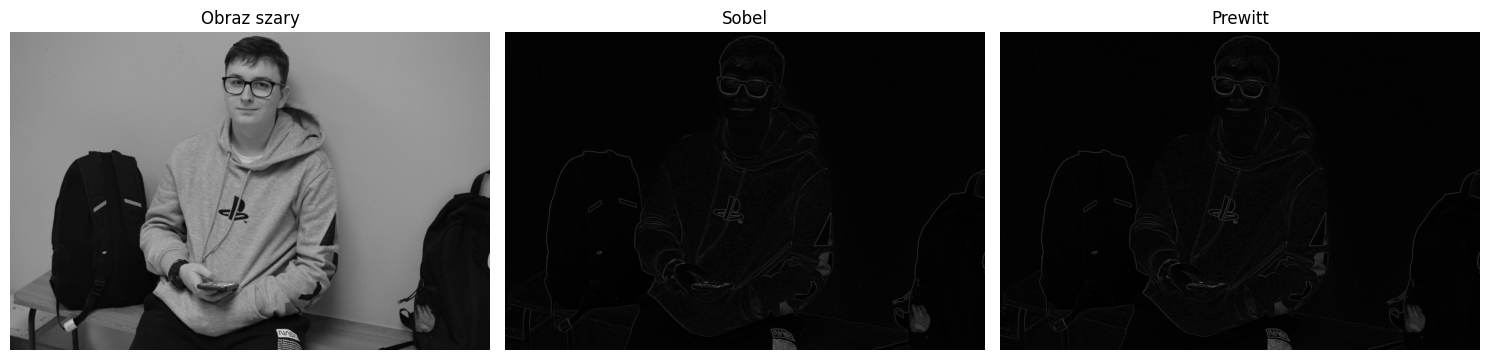

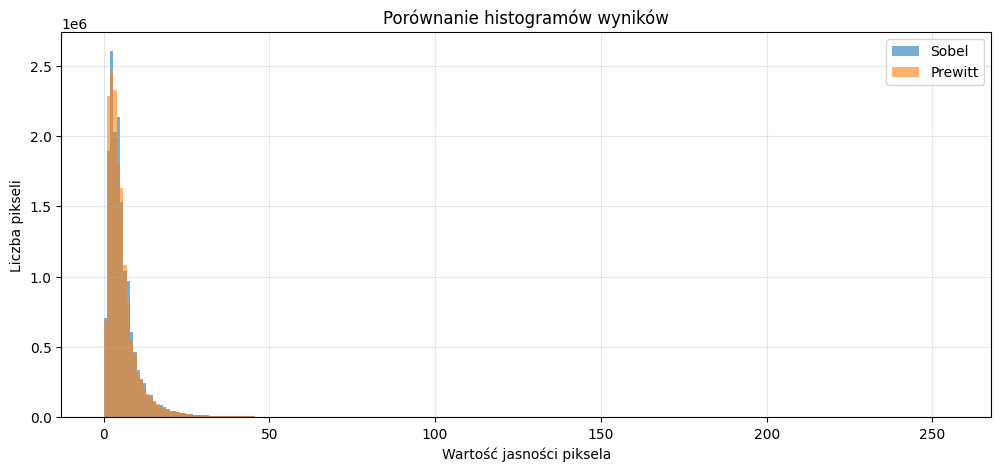

Sobel - średnia jasność: 5.67
Sobel - maksymalna jasność: 255
Prewitt - średnia jasność: 5.48
Prewitt - maksymalna jasność: 255


In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

# Wczytanie obrazu i konwersja do skali szarości
image = Image.open('chlopak.JPG')
gray = image.convert('L')

# Funkcja pomocnicza: splot maską 3x3 oraz wyznaczenie krawędzi z gradientów
def convolution_3x3(image_array, kernel):
    kernel = np.array(kernel, dtype=np.float32).reshape(3, 3)
    padded = np.pad(image_array, 1, mode='edge')

    result = (
        kernel[0, 0] * padded[:-2, :-2] + kernel[0, 1] * padded[:-2, 1:-1] + kernel[0, 2] * padded[:-2, 2:] +
        kernel[1, 0] * padded[1:-1, :-2] + kernel[1, 1] * padded[1:-1, 1:-1] + kernel[1, 2] * padded[1:-1, 2:] +
        kernel[2, 0] * padded[2:, :-2] + kernel[2, 1] * padded[2:, 1:-1] + kernel[2, 2] * padded[2:, 2:]
    )

    return result


def gradient_edges(image_gray, kernel_x, kernel_y):
    image_array = np.array(image_gray, dtype=np.float32)

    gx = convolution_3x3(image_array, kernel_x)
    gy = convolution_3x3(image_array, kernel_y)

    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    magnitude = magnitude / magnitude.max() * 255

    return Image.fromarray(magnitude.astype(np.uint8))


# Operator Sobela
sobel_x = [-1, 0, 1,
           -2, 0, 2,
           -1, 0, 1]

sobel_y = [-1, -2, -1,
            0,  0,  0,
            1,  2,  1]

sobel_result = gradient_edges(gray, sobel_x, sobel_y)

# Operator Prewitta
prewitt_x = [-1, 0, 1,
             -1, 0, 1,
             -1, 0, 1]

prewitt_y = [-1, -1, -1,
              0,  0,  0,
              1,  1,  1]

prewitt_result = gradient_edges(gray, prewitt_x, prewitt_y)

# Porównanie wyników
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

images = [gray, sobel_result, prewitt_result]
titles = ['Obraz szary', 'Sobel', 'Prewitt']

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Porównanie histogramów obu wyników
sobel_array = np.array(sobel_result)
prewitt_array = np.array(prewitt_result)

plt.figure(figsize=(12, 5))
plt.hist(sobel_array.ravel(), bins=256, range=(0, 255), alpha=0.6, label='Sobel')
plt.hist(prewitt_array.ravel(), bins=256, range=(0, 255), alpha=0.6, label='Prewitt')
plt.title('Porównanie histogramów wyników')
plt.xlabel('Wartość jasności piksela')
plt.ylabel('Liczba pikseli')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Statystyki porównawcze
print('Sobel - średnia jasność:', round(sobel_array.mean(), 2))
print('Sobel - maksymalna jasność:', sobel_array.max())
print('Prewitt - średnia jasność:', round(prewitt_array.mean(), 2))
print('Prewitt - maksymalna jasność:', prewitt_array.max())

## Wnioski

Oba operatory poprawnie wykrywają krawędzie na obrazie. Wyniki są do siebie podobne, ponieważ zarówno Sobel, jak i Prewitt obliczają zmianę jasności w kierunku poziomym i pionowym. Operator Sobela daje zwykle mocniejsze i bardziej kontrastowe krawędzie, ponieważ jego maska nadaje większą wagę pikselom położonym bliżej środka. Operator Prewitta jest prostszy i może dawać nieco delikatniejszy wynik.

Na histogramach można zauważyć, że dla obu metod najwięcej pikseli znajduje się przy niskich wartościach jasności. Oznacza to, że większość obszaru obrazu nie zawiera silnych krawędzi. Piksele o większej jasności odpowiadają miejscom, gdzie zmiana intensywności jest największa, czyli konturom i szczegółom obrazu.